# Credit Card Fraud Detection using XGBoost and SMOTE

This notebook demonstrates how to detect rare fraudulent transactions.

Workflow:
1. Create an imbalanced dataset.
2. Split training and testing data.
3. Apply SMOTE only to training data.
4. Train XGBoost.
5. Predict fraud probabilities.
6. Tune the decision threshold.
7. Inspect feature importance.

This uses synthetic data for learning; a real project would use a cleaned transaction dataset.


In [13]:
# Install these packages in a separate cell if needed:
# %pip install numpy pandas matplotlib scikit-learn imbalanced-learn xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


## 1. Load the real transaction dataset

The notebook now uses the uploaded `train_transaction` dataset instead of creating a synthetic dataset.

The rest of the workflow is kept the same.


In [ ]:
df = pd.read_csv("/content/train_transaction.csv")
df = df.rename(columns={"isFraud": "is_fraud"})

features = df.select_dtypes(include=np.number).columns.tolist()
features.remove("is_fraud")

df = df[features[:8] + ["is_fraud"]].dropna()

display(df.head())
print(df.shape)
print(df["is_fraud"].value_counts())


,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,is_fraud
1,2987001,86401,29.0,2755,404.0,150.0,102.0,325.0,0
2,2987002,86469,59.0,4663,490.0,150.0,166.0,330.0,0
3,2987003,86499,50.0,18132,567.0,150.0,117.0,476.0,0
4,2987004,86506,50.0,4497,514.0,150.0,102.0,420.0,0
5,2987005,86510,49.0,5937,555.0,150.0,226.0,272.0,0


(107314, 9)
is_fraud
0    105378
1      1936
Name: count, dtype: int64


## 2. Split the data

`X` contains transaction features. `y` contains the target:
- `0` = legitimate
- `1` = fraudulent

Stratification keeps a similar fraud percentage in both sets.


In [ ]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=10
)

print("Training fraud rate:", round(y_train.mean() * 100, 2), "%")
print("Testing fraud rate:", round(y_test.mean() * 100, 2), "%")


Training fraud rate: 1.8 %
Testing fraud rate: 1.8 %


## 3. Apply SMOTE

**SMOTE** creates synthetic minority-class examples instead of simply copying existing fraud rows.

It is applied only to the training set so the test set remains realistic and untouched.


In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=10)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train, y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


Before SMOTE:
is_fraud
0    84302
1     1549
Name: count, dtype: int64

After SMOTE:
is_fraud
0    84302
1    84302
Name: count, dtype: int64


## 4. Train XGBoost

**XGBoost** builds decision trees sequentially. Each new tree tries to correct errors made by earlier trees, allowing it to learn complex nonlinear patterns.


In [ ]:
model = XGBClassifier(
    n_estimators=160,
    max_depth=5,
    learning_rate=0.06,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=10
)

model.fit(X_train_resampled, y_train_resampled)
print("Training completed.")


Training completed.


## 5. Predict fraud probabilities

`predict_proba()` returns class probabilities. Column `1` is the estimated probability that a transaction is fraudulent.


In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "actual_fraud": y_test.values,
    "fraud_probability": y_prob
})

display(results.head(10))


,actual_fraud,fraud_probability
0,0,0.039472
1,0,0.477090
2,0,0.260990
3,0,0.111972
4,0,0.123873
5,0,0.124896
6,0,0.423615
7,0,0.333923
8,0,0.288800
9,0,0.173031


## 6. Evaluate ranking performance

- **ROC-AUC** measures how well the model ranks fraud above legitimate transactions.
- **PR-AUC** is particularly useful for imbalanced data because it focuses on precision and recall.


In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC:  {pr_auc:.3f}")


ROC-AUC: 0.752
PR-AUC:  0.102


## 7. Tune the decision threshold

The default threshold is usually `0.5`, but fraud detection may use a lower threshold because missing fraud can be costly.

A lower threshold usually increases recall, but it can also increase false positives.


In [ ]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.80]
threshold_results = []

for threshold in thresholds:
    # Convert probabilities into 0/1 predictions.
    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "recall": recall_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "f1_score": f1_score(
            y_test, y_pred_threshold, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.round(3))


,threshold,precision,recall,f1_score
0,0.2,0.036,0.693,0.069
1,0.3,0.050,0.525,0.092
2,0.4,0.068,0.377,0.115
3,0.5,0.102,0.279,0.149
4,0.6,0.146,0.181,0.162
5,0.8,0.304,0.054,0.092


## 8. Evaluate a selected threshold

We use `0.30` only as a demonstration. In a real system, select the threshold using validation data and the costs of false positives and false negatives.


In [ ]:
chosen_threshold = 0.35
y_pred = (y_prob >= chosen_threshold).astype(int)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))


Confusion matrix:
[[18254  2822]
 [  221   166]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.92     21076
           1       0.06      0.43      0.10       387

    accuracy                           0.86     21463
   macro avg       0.52      0.65      0.51     21463
weighted avg       0.97      0.86      0.91     21463



## 9. Inspect feature importance

Feature importance shows which features the trained XGBoost model relied on when building its trees.

High importance does not prove that a feature causes fraud; it only means that the feature helped the model make predictions.


,feature,importance
5,card3,0.241866
6,card5,0.204975
2,TransactionAmt,0.151809
7,addr1,0.142792
4,card2,0.130571
3,card1,0.048044
1,TransactionDT,0.046479
0,TransactionID,0.033464


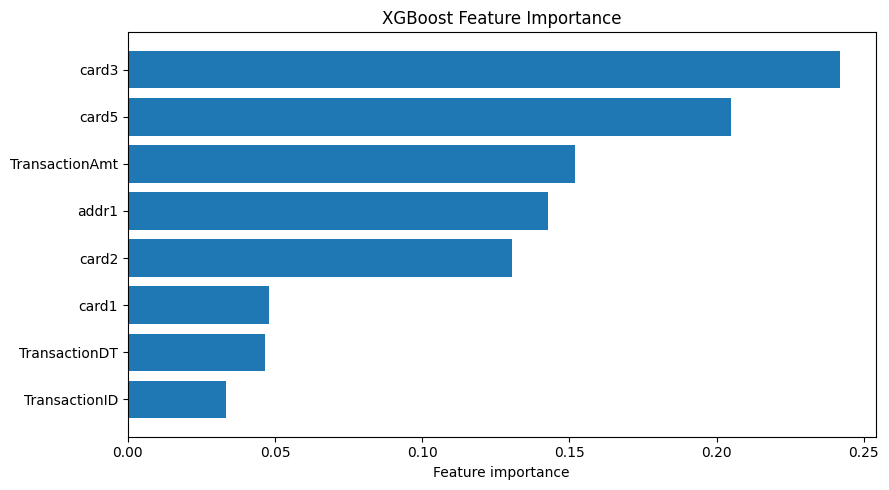

In [ ]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(9, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()
